# Figure2S-4S: GO enrichment/Over-representation analysis (ORA) #

Gene ontology data were exported from gProfiler https://biit.cs.ut.ee/gprofiler/gost as .csv files

## Figure 2S - Cytoskeleton database enrichment ##

Loaded: C:/Users/Brandi/OneDrive/Desktop/Proteomics manuscript/Perseus files for manuscript/GO-ORA_results/gprofiler_CytoskeletalDB-v-fig4list.csv
Saved: C:/Users/Brandi/OneDrive/Desktop/Proteomics manuscript/Perseus files for manuscript/GO-ORA_results/CDB_bar_svg.svg


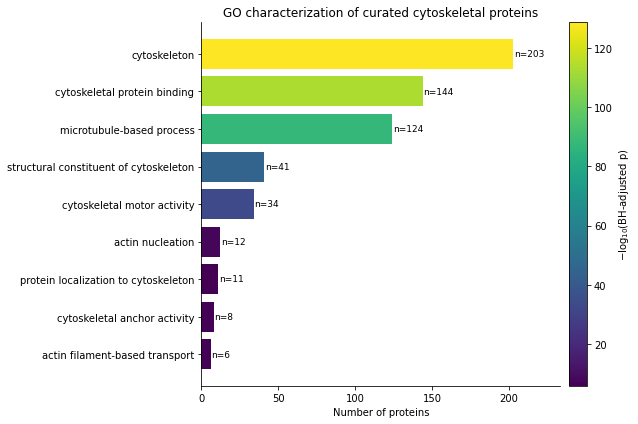

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ============================================================
# 1. SELECT g:PROFILER CSV
# ============================================================

root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

file_path = filedialog.askopenfilename(
    title="Select g:Profiler intersections CSV",
    filetypes=[
        ("CSV files", "*.csv"),
        ("All files", "*.*")
    ]
)

root.destroy()

df = pd.read_csv(file_path)

print("Loaded:", file_path)


# ============================================================
# 2. TERMS TO DISPLAY
#    Edit using exact g:Profiler term names
# ============================================================

terms_to_plot = [
    "cytoskeleton",
    "cytoskeletal protein binding",
    "microtubule-based process",
    "cytoskeletal motor activity",
    "structural constituent of cytoskeleton",
    "actin nucleation",
    "protein localization to cytoskeleton",
    "dynein binding",
    "cytoskeletal anchor activity",
    "microtubule nucleator activity",
    "actin filament-based transport"
]


# ============================================================
# 3. FILTER DATA
# ============================================================

plot_df = df[
    df["term_name"].str.lower().isin(
        [term.lower() for term in terms_to_plot]
    )
].copy()

plot_df = plot_df[
    plot_df["adjusted_p_value"] < 0.05
].copy()

# Calculate -log10 adjusted p
plot_df["neglog10_padj"] = -np.log10(
    plot_df["adjusted_p_value"]
)

# Sort by protein count
plot_df = plot_df.sort_values(
    "intersection_size",
    ascending=True
)


# ============================================================
# 4. MAP SIGNIFICANCE TO COLOR
# ============================================================

norm = Normalize(
    vmin=plot_df["neglog10_padj"].min(),
    vmax=plot_df["neglog10_padj"].max()
)

cmap = plt.cm.viridis

bar_colors = cmap(
    norm(plot_df["neglog10_padj"])
)


# ============================================================
# 5. PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    plot_df["term_name"],
    plot_df["intersection_size"],
    color=bar_colors
)

ax.set_xlabel("Number of proteins")
ax.set_ylabel("")
ax.set_title(
    "GO characterization of curated cytoskeletal proteins"
)

# Add protein count to end of each bar
for bar, n in zip(
    bars,
    plot_df["intersection_size"]
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"n={int(n)}",
        va="center",
        fontsize=9
    )

ax.set_xlim(
    0,
    plot_df["intersection_size"].max() * 1.15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ============================================================
# 6. COLORBAR FOR SIGNIFICANCE
# ============================================================

sm = ScalarMappable(
    norm=norm,
    cmap=cmap
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    r"$-\log_{10}$(BH-adjusted p)"
)


plt.tight_layout()


# ============================================================
# 7. SAVE WITH POPUP
# ============================================================

root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

save_path = filedialog.asksaveasfilename(
    title="Save GO annotation plot",
    defaultextension=".pdf",
    filetypes=[
        ("PDF", "*.pdf"),
        ("SVG", "*.svg"),
        ("PNG", "*.png"),
        ("TIFF", "*.tiff")
    ]
)

root.destroy()

if save_path:
    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=600
    )
    print("Saved:", save_path)

plt.show()

## Figure 4S: WT-Enriched (>1-fold) terms ##

Loaded: C:/Users/Brandi/OneDrive/Desktop/Proteomics manuscript/Perseus files for manuscript/GO-ORA_results/gprofiler_WTenriched-v-fig4list.csv
Saved: C:/Users/Brandi/OneDrive/Desktop/Proteomics manuscript/Perseus files for manuscript/GO-ORA_results/Enriched_bar_svg.svg


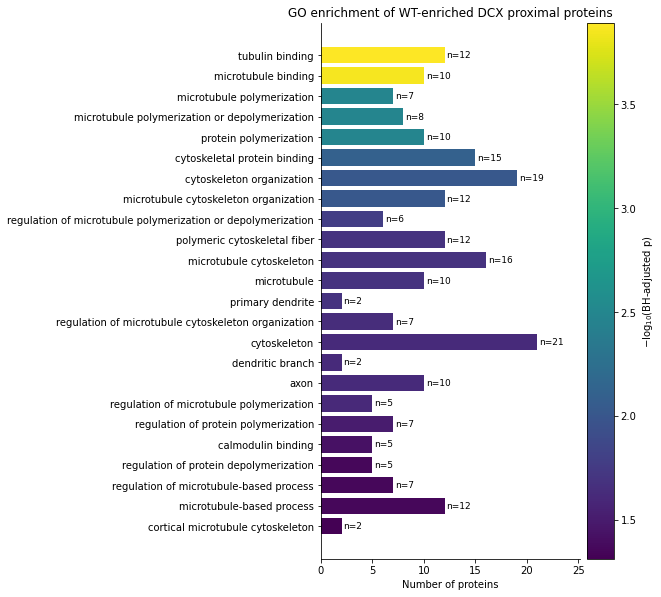

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ============================================================
# 1. SELECT g:PROFILER CSV
# ============================================================

root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

file_path = filedialog.askopenfilename(
    title="Select g:Profiler intersections CSV",
    filetypes=[
        ("CSV files", "*.csv"),
        ("All files", "*.*")
    ]
)

root.destroy()

df = pd.read_csv(file_path)

print("Loaded:", file_path)


# ============================================================
# 2. KEEP SIGNIFICANT GO TERMS ONLY
# ============================================================

plot_df = df[
    (df["adjusted_p_value"] < 0.05) &
    (df["source"].isin(["GO:MF", "GO:BP", "GO:CC"]))
].copy()

# Calculate -log10 adjusted p-value
plot_df["neglog10_padj"] = -np.log10(
    plot_df["adjusted_p_value"]
)


# ============================================================
# 3. OPTIONAL: KEEP ONLY CYTOSKELETAL / MT-RELATED TERMS
#    Comment this whole block out if you want ALL significant GO terms
# ============================================================

keywords = [
    "microtubule",
    "tubulin",
    "cytoskeleton",
    "cytoskeletal",
    "axon",
    "dendrite",
    "branch",
    "polymerization",
    "depolymerization",
    "calmodulin"
]

pattern = "|".join(keywords)

plot_df = plot_df[
    plot_df["term_name"].str.contains(
        pattern,
        case=False,
        na=False
    )
].copy()


# ============================================================
# 4. SORT BY SIGNIFICANCE
#    Most significant term appears at TOP
# ============================================================

plot_df = plot_df.sort_values(
    "adjusted_p_value",
    ascending=False
)


# ============================================================
# 5. COLOR = SIGNIFICANCE
# ============================================================

norm = Normalize(
    vmin=plot_df["neglog10_padj"].min(),
    vmax=plot_df["neglog10_padj"].max()
)

cmap = plt.cm.viridis

bar_colors = cmap(
    norm(plot_df["neglog10_padj"])
)


# ============================================================
# 6. PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, max(5, len(plot_df) * 0.35))
)

bars = ax.barh(
    plot_df["term_name"],
    plot_df["intersection_size"],
    color=bar_colors
)

ax.set_xlabel("Number of proteins")
ax.set_ylabel("")
ax.set_title(
    "GO enrichment of WT-enriched DCX proximal proteins"
)

# Add n values at end of bars
for bar, n in zip(
    bars,
    plot_df["intersection_size"]
):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"n={int(n)}",
        va="center",
        fontsize=9
    )

# Leave room for n labels
ax.set_xlim(
    0,
    plot_df["intersection_size"].max() * 1.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ============================================================
# 7. COLORBAR
# ============================================================

sm = ScalarMappable(
    norm=norm,
    cmap=cmap
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.02
)

cbar.set_label(
    r"$-\log_{10}$(BH-adjusted p)"
)


plt.tight_layout()


# ============================================================
# 8. SAVE WITH POPUP
# ============================================================

root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

save_path = filedialog.asksaveasfilename(
    title="Save GO enrichment bar plot",
    defaultextension=".pdf",
    filetypes=[
        ("PDF", "*.pdf"),
        ("SVG", "*.svg"),
        ("PNG", "*.png"),
        ("TIFF", "*.tiff")
    ]
)

root.destroy()

if save_path:
    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=600
    )
    print("Saved:", save_path)

plt.show()